## Ahmed Mohamed Abdelhamid: 221011073
## Omar Khaled Basha: 221002374
## Ahmed Mohamed Hamimi: 221011417

# Information Retrieval - Week 7 Project
## Search Engine for Shakespeare's Books

This notebook implements a mini search engine over the Shakespeare corpus. It covers:

- **Section 1**: Dataset loading and preprocessing
- **Section 2**: Indexing — Term-Document Incidence Matrix (TDIM), Inverted Index / Direct Index, Binary Search Tree (BST)
- **Section 3**: Query parsing and processing with Boolean operators, spelling correction, and display control
- **Section 4**: Evaluation — Precision and Recall at multiple cutoffs over 20 Boolean queries
- **Section 5**: Visualizations

---
## Section 0 — Imports and Setup

All required libraries are imported here. We use `nltk` for tokenization, stopword removal, lemmatization, and stemming. `time` is used throughout for performance measurement. `matplotlib` and `seaborn` are used for visualizations.

In [35]:
import os
import re
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import defaultdict

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)

matplotlib.rcParams['figure.dpi'] = 120
plt.style.use('seaborn-v0_8-whitegrid')

print('All imports successful.')

All imports successful.


---
## Section 1 — Dataset Loading

Each file in the `books/` directory corresponds to one Shakespeare work. We load all 43 files into a dictionary mapping a numeric document ID (1-indexed, matching the filename prefix) to its raw text content, and separately maintain a mapping from that numeric ID to the book title (filename without extension).

In [36]:
#===========================
# LOAD EVERY BOOK FILE FROM THE books/ DIRECTORY
# doc_id IS THE INTEGER PREFIX IN THE FILENAME (e.g. "8. HAMLET..." -> 8)
#===========================

BOOKS_DIR = './books'

raw_corpus = {}       # doc_id (int) -> raw text (str)
id_to_title = {}      # doc_id (int) -> title string

file_names = os.listdir(BOOKS_DIR)
file_names = sorted(file_names, key=lambda x: int(re.search(r'^\d+', x).group()))

for fname in file_names:
    match = re.search(r'^(\d+)\.\s+(.+)\.txt$', fname)
    if match:
        doc_id = int(match.group(1))
        title  = match.group(2).strip()
        fpath  = os.path.join(BOOKS_DIR, fname)
        with open(fpath, 'r', encoding='utf-8') as f:
            raw_corpus[doc_id] = f.read()
        id_to_title[doc_id] = title

ALL_DOC_IDS = sorted(raw_corpus.keys())
N_DOCS = len(ALL_DOC_IDS)

print(f'Loaded {N_DOCS} documents.')
print(f'Doc IDs range: {ALL_DOC_IDS[0]} to {ALL_DOC_IDS[-1]}')
print()
print('Sample entries:')
for did in ALL_DOC_IDS[:5]:
    print(f'  [{did}] {id_to_title[did]}  ({len(raw_corpus[did])} chars)')

Loaded 43 documents.
Doc IDs range: 1 to 44

Sample entries:
  [1] THE SONNETS  (91502 chars)
  [2] ALLS WELL THAT ENDS WELL  (127306 chars)
  [3] THE TRAGEDY OF ANTONY AND CLEOPATRA  (143794 chars)
  [4] AS YOU LIKE IT  (119310 chars)
  [5] THE COMEDY OF ERRORS  (83856 chars)


### 1.1 — Corpus Overview Visualization

We plot the character count of each book to get a sense of the size distribution across the corpus.

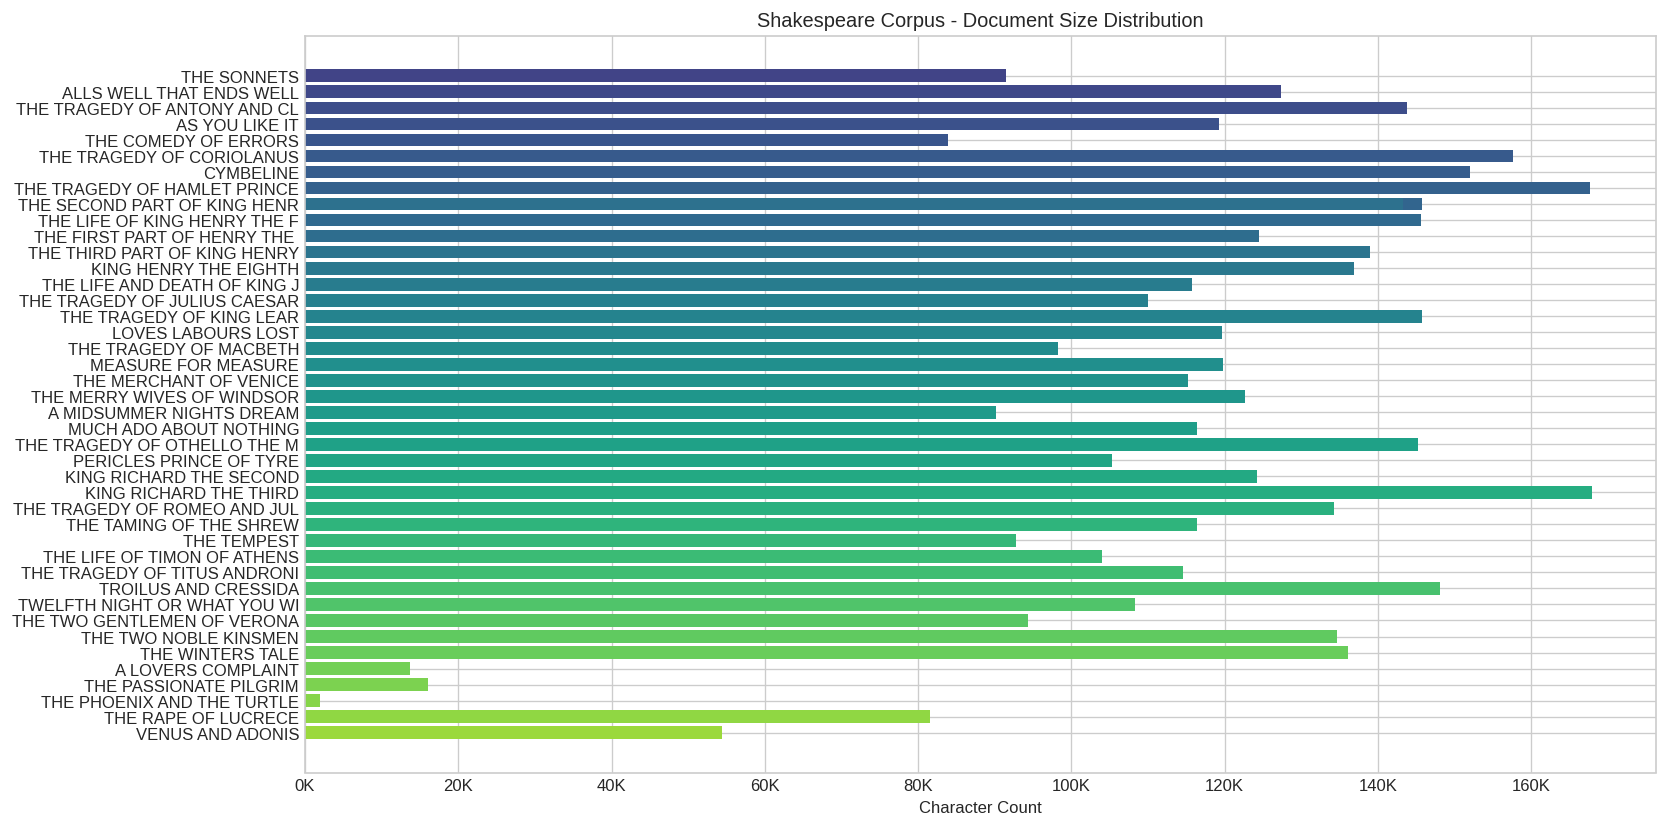

Average document size: 114,555 characters
Largest:  KING RICHARD THE THIRD  (167,896 chars)
Smallest: THE PHOENIX AND THE TURTLE  (1,981 chars)


In [37]:
#===========================
# VISUALIZE DOCUMENT SIZE DISTRIBUTION BY CHARACTER COUNT
#===========================

sizes  = [len(raw_corpus[did]) for did in ALL_DOC_IDS]
titles_short = [id_to_title[did][:28] for did in ALL_DOC_IDS]

fig, ax = plt.subplots(figsize=(14, 7))
colors = plt.cm.viridis(np.linspace(0.2, 0.85, N_DOCS))
bars = ax.barh(titles_short, sizes, color=colors)
ax.set_xlabel('Character Count')
ax.set_title('Shakespeare Corpus - Document Size Distribution')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
plt.tight_layout()
plt.show()
print(f'Average document size: {int(np.mean(sizes)):,} characters')
print(f'Largest:  {id_to_title[ALL_DOC_IDS[np.argmax(sizes)]]}  ({max(sizes):,} chars)')
print(f'Smallest: {id_to_title[ALL_DOC_IDS[np.argmin(sizes)]]}  ({min(sizes):,} chars)')

---
## Section 2 — Preprocessing

Before indexing, every document goes through the following normalization pipeline:

1. **Case folding** — convert all text to lowercase.
2. **Tokenization** — split into individual word tokens.
3. **Alphanumeric filtering** — discard punctuation and special characters.
4. **Stop word removal** — remove common English function words.
5. **Lemmatization** — reduce words to their base dictionary form (WordNetLemmatizer).
6. **Stemming** — further reduce lemmas to their stem (PorterStemmer).

This pipeline is taken directly from the lab reference notebooks and applied here at scale over the full corpus.

In [38]:
#===========================
# PREPROCESSING PIPELINE: CASE FOLD -> TOKENIZE -> FILTER -> LEMMATIZE -> STEM
# RETURNS A LIST OF PROCESSED TOKENS FOR A GIVEN TEXT STRING
#===========================

lemmatizer = WordNetLemmatizer()
stemmer    = PorterStemmer()
STOP_WORDS = set(stopwords.words('english'))

def preprocess_text(text):
    text   = text.lower()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t.isalnum() and t not in STOP_WORDS]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    tokens = [stemmer.stem(t) for t in tokens]
    return tokens


print('Preprocessing all 43 documents...')
t0 = time.time()

processed_corpus = {}   # doc_id (int) -> list of processed tokens
for did in ALL_DOC_IDS:
    processed_corpus[did] = preprocess_text(raw_corpus[did])

t1 = time.time()
print(f'Preprocessing complete in {t1 - t0:.3f} seconds.')
print()

example_id = 8
sample_raw    = raw_corpus[example_id][:200].replace('\n', ' ')
sample_tokens = processed_corpus[example_id][:20]
print(f'Example — [{example_id}] {id_to_title[example_id]}')
print(f'  Raw (first 200 chars): {sample_raw}')
print(f'  First 20 processed tokens: {sample_tokens}')

Preprocessing all 43 documents...
Preprocessing complete in 7.257 seconds.

Example — [8] THE TRAGEDY OF HAMLET PRINCE OF DENMARK
  Raw (first 200 chars): THE TRAGEDY OF HAMLET PRINCE OF DENMARK     Contents  ACT I Scene I Elsinore A platform before the Castle Scene II Elsinore A room of state in the Castle Scene III A room in Poloniuss house Scene IV T
  First 20 processed tokens: ['tragedi', 'hamlet', 'princ', 'denmark', 'content', 'act', 'scene', 'elsinor', 'platform', 'castl', 'scene', 'ii', 'elsinor', 'room', 'state', 'castl', 'scene', 'iii', 'room', 'poloniuss']


### 2.1 — Vocabulary and Token Statistics

We build the global vocabulary (set of unique terms across all documents after preprocessing) and display statistics.

Total tokens across corpus : 501,200
Unique terms (vocabulary)  : 20,237
Average tokens per document: 11,655


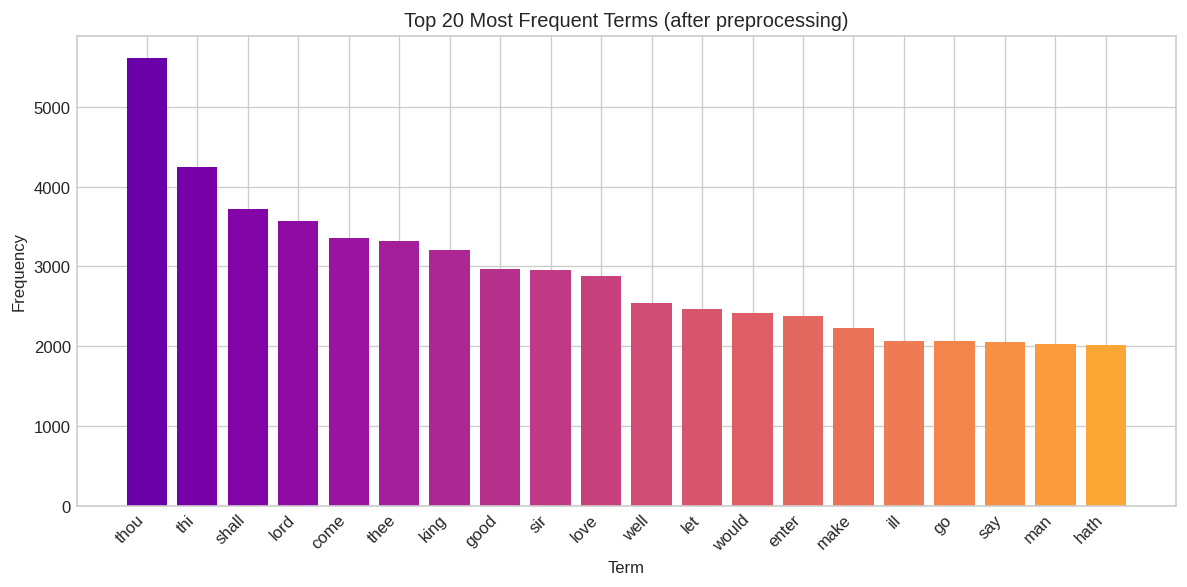

In [39]:
#===========================
# BUILD GLOBAL VOCABULARY FROM ALL PROCESSED TOKENS
#===========================

all_tokens = []
for did in ALL_DOC_IDS:
    all_tokens.extend(processed_corpus[did])

VOCABULARY = sorted(set(all_tokens))
VOCAB_SET  = set(VOCABULARY)

print(f'Total tokens across corpus : {len(all_tokens):,}')
print(f'Unique terms (vocabulary)  : {len(VOCABULARY):,}')
print(f'Average tokens per document: {int(len(all_tokens) / N_DOCS):,}')

#===========================
# TOP-20 MOST FREQUENT TERMS ACROSS CORPUS
#===========================
from collections import Counter
global_freq = Counter(all_tokens)
top20 = global_freq.most_common(20)

fig, ax = plt.subplots(figsize=(10, 5))
terms_top, counts_top = zip(*top20)
ax.bar(terms_top, counts_top, color=plt.cm.plasma(np.linspace(0.2, 0.8, 20)))
ax.set_title('Top 20 Most Frequent Terms (after preprocessing)')
ax.set_xlabel('Term')
ax.set_ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## Section 3 — Indexing

We implement three indexing models as required by the project specification. For each model we measure and display the time taken to construct the index.

---
### 3.1 — Term-Document Incidence Matrix (TDIM)

A binary matrix where rows are unique terms and columns are documents. Cell value is 1 if the term appears in the document and 0 otherwise. This follows the implementation demonstrated in Lab 2 (IR_lab2_BooleanRetrieval).

For the full 43-document corpus the matrix is stored as a dictionary mapping each term to a list of 43 binary integers.

In [40]:
#===========================
# BUILD TERM-DOCUMENT INCIDENCE MATRIX
# ROW = TERM, COLUMN = DOCUMENT (ordered by ALL_DOC_IDS)
# CELL VALUE = 1 IF TERM EXISTS IN DOCUMENT, ELSE 0
#===========================

def build_tdim(processed_corpus, all_doc_ids, vocabulary):
    doc_token_sets = {did: set(processed_corpus[did]) for did in all_doc_ids}
    matrix = {}
    for term in vocabulary:
        vector = []
        for did in all_doc_ids:
            vector.append(1 if term in doc_token_sets[did] else 0)
        matrix[term] = vector
    return matrix


print('Building Term-Document Incidence Matrix...')
t0 = time.time()
TDIM = build_tdim(processed_corpus, ALL_DOC_IDS, VOCABULARY)
t1 = time.time()
TDIM_BUILD_TIME = t1 - t0
print(f'TDIM built in {TDIM_BUILD_TIME:.4f} seconds.')
print(f'Matrix size: {len(VOCABULARY):,} terms x {N_DOCS} documents')

#===========================
# HELPER: RETRIEVE INCIDENCE VECTOR FOR A SINGLE TERM
#===========================
def term_incidence_vector(term, tdim):
    return tdim.get(term, None)

example_term = 'love'
stemmed_example = stemmer.stem(lemmatizer.lemmatize(example_term))
vec = term_incidence_vector(stemmed_example, TDIM)
if vec:
    docs_with_term = [ALL_DOC_IDS[i] for i, v in enumerate(vec) if v == 1]
    print(f'\nTerm "{example_term}" (stemmed: "{stemmed_example}") appears in {len(docs_with_term)} documents.')

Building Term-Document Incidence Matrix...
TDIM built in 0.1500 seconds.
Matrix size: 20,237 terms x 43 documents

Term "love" (stemmed: "love") appears in 43 documents.


#### TDIM Visualization — Heatmap (sample of top terms)

We display a heatmap of a representative slice of the TDIM to visually confirm its structure.

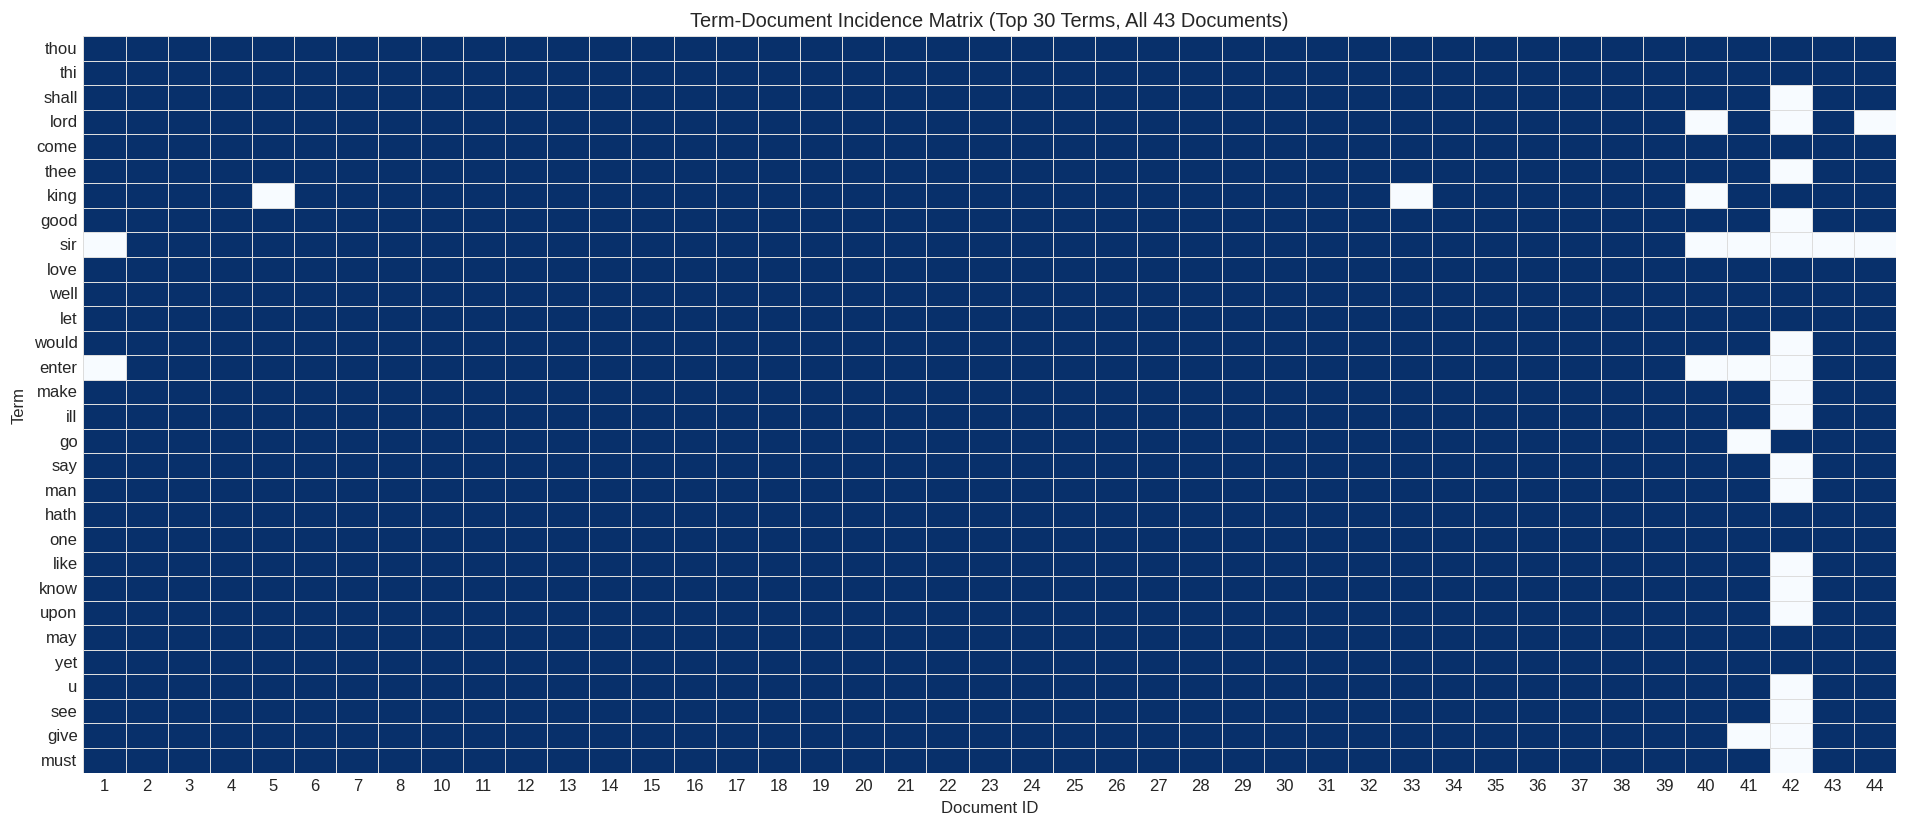

In [41]:
#===========================
# VISUALIZE A 30-TERM SLICE OF THE TDIM AS A HEATMAP
# TERMS ARE SELECTED AS THE 30 MOST FREQUENT IN THE CORPUS
#===========================

top_terms_for_viz = [t for t, _ in global_freq.most_common(30)]
matrix_slice = np.array([TDIM[t] for t in top_terms_for_viz])
short_titles  = [str(did) for did in ALL_DOC_IDS]

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(
    matrix_slice,
    ax=ax,
    xticklabels=short_titles,
    yticklabels=top_terms_for_viz,
    cmap='Blues',
    cbar=False,
    linewidths=0.3,
    linecolor='#dddddd'
)
ax.set_title('Term-Document Incidence Matrix (Top 30 Terms, All 43 Documents)')
ax.set_xlabel('Document ID')
ax.set_ylabel('Term')
plt.tight_layout()
plt.show()

---
### 3.2 — Inverted Index and Direct Index

The **inverted index** maps each term to a sorted posting list of document IDs in which it appears, along with the term frequency in each document.

The **direct index** maps each document ID to a list of (term, frequency) pairs for the terms present in that document.

This mirrors the data structures described in Lab 5 (IR_Lab5 using PyTerrier) but implemented natively in Python without the Terrier dependency.

In [42]:
#===========================
# BUILD INVERTED INDEX: term -> sorted list of (doc_id, term_freq) tuples
# BUILD DIRECT INDEX:   doc_id -> list of (term, term_freq) tuples
#===========================

def build_inverted_and_direct_index(processed_corpus, all_doc_ids):
    inverted = defaultdict(list)   # term -> [(doc_id, tf), ...]
    direct   = {}                  # doc_id -> [(term, tf), ...]

    for did in all_doc_ids:
        tokens    = processed_corpus[did]
        term_freq = Counter(tokens)
        direct[did] = sorted(term_freq.items())
        for term, freq in term_freq.items():
            inverted[term].append((did, freq))

    #===========================
    # SORT POSTING LISTS BY DOC_ID FOR EFFICIENT MERGE OPERATIONS
    #===========================
    for term in inverted:
        inverted[term].sort(key=lambda x: x[0])

    return dict(inverted), direct


print('Building Inverted Index and Direct Index...')
t0 = time.time()
INVERTED_INDEX, DIRECT_INDEX = build_inverted_and_direct_index(processed_corpus, ALL_DOC_IDS)
t1 = time.time()
INV_BUILD_TIME = t1 - t0
print(f'Inverted + Direct Index built in {INV_BUILD_TIME:.4f} seconds.')
print(f'Unique terms indexed: {len(INVERTED_INDEX):,}')

#===========================
# SAMPLE LOOKUP: SHOW POSTING LIST FOR A TERM
#===========================
sample_term = stemmer.stem(lemmatizer.lemmatize('love'))
postings    = INVERTED_INDEX.get(sample_term, [])
print(f'\nPosting list for "{sample_term}" (first 10 entries):')
for doc_id, tf in postings[:10]:
    print(f'  doc {doc_id:2d} ({id_to_title[doc_id][:30]}) -> tf={tf}')

Building Inverted Index and Direct Index...
Inverted + Direct Index built in 0.1522 seconds.
Unique terms indexed: 20,237

Posting list for "love" (first 10 entries):
  doc  1 (THE SONNETS) -> tf=218
  doc  2 (ALLS WELL THAT ENDS WELL) -> tf=76
  doc  3 (THE TRAGEDY OF ANTONY AND CLEO) -> tf=56
  doc  4 (AS YOU LIKE IT) -> tf=144
  doc  5 (THE COMEDY OF ERRORS) -> tf=19
  doc  6 (THE TRAGEDY OF CORIOLANUS) -> tf=53
  doc  7 (CYMBELINE) -> tf=36
  doc  8 (THE TRAGEDY OF HAMLET PRINCE O) -> tf=80
  doc 10 (THE SECOND PART OF KING HENRY ) -> tf=28
  doc 11 (THE LIFE OF KING HENRY THE FIF) -> tf=45


#### Inverted Index Visualization — Document Frequency Distribution

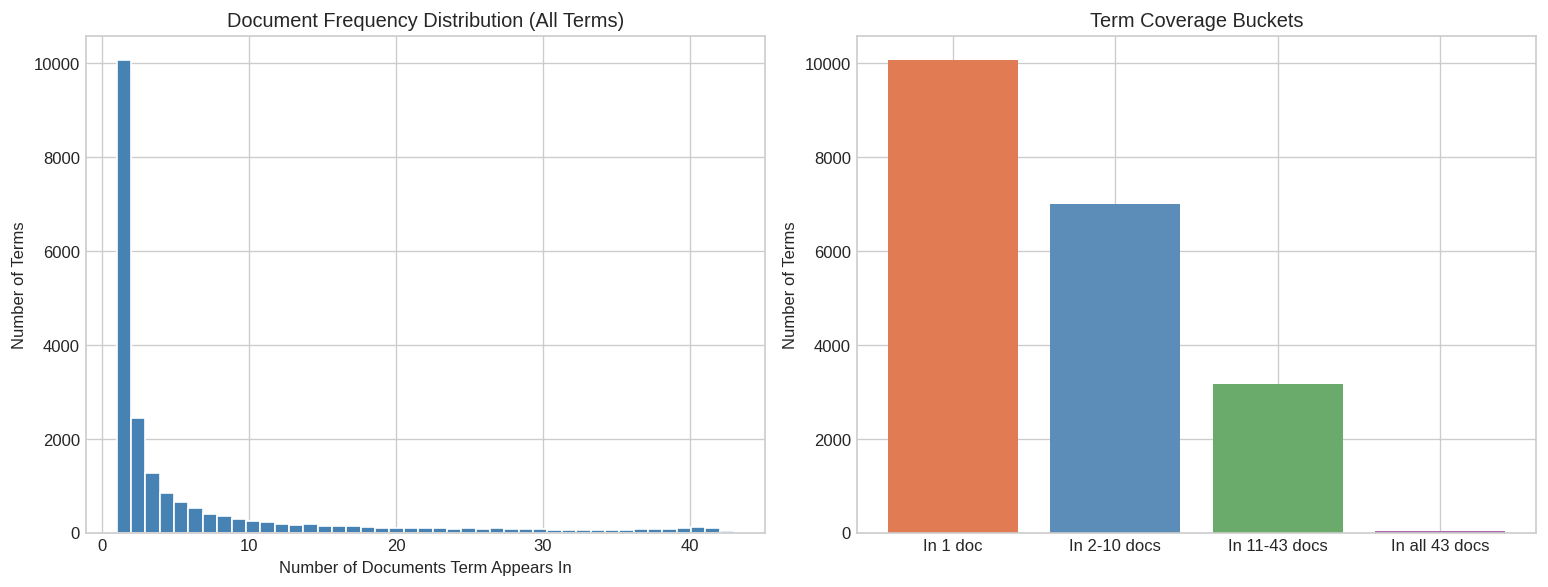

Terms appearing in all 43 documents: 31


In [43]:
#===========================
# PLOT DISTRIBUTION OF DOCUMENT FREQUENCY (df) ACROSS ALL TERMS
#===========================

doc_freqs = [len(postings) for postings in INVERTED_INDEX.values()]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(doc_freqs, bins=43, color='steelblue', edgecolor='white')
axes[0].set_title('Document Frequency Distribution (All Terms)')
axes[0].set_xlabel('Number of Documents Term Appears In')
axes[0].set_ylabel('Number of Terms')

#===========================
# TERMS PRESENT IN ALL 43 DOCUMENTS (UNIVERSAL TERMS)
#===========================
universal = [t for t, pl in INVERTED_INDEX.items() if len(pl) == N_DOCS]
axes[1].bar(
    ['In 1 doc', 'In 2-10 docs', 'In 11-43 docs', 'In all 43 docs'],
    [
        sum(1 for d in doc_freqs if d == 1),
        sum(1 for d in doc_freqs if 2 <= d <= 10),
        sum(1 for d in doc_freqs if 11 <= d <= 43),
        len(universal)
    ],
    color=['#e07b54', '#5b8db8', '#6aaa6a', '#aa6aaa']
)
axes[1].set_title('Term Coverage Buckets')
axes[1].set_ylabel('Number of Terms')

plt.tight_layout()
plt.show()
print(f'Terms appearing in all 43 documents: {len(universal)}')

---
### 3.3 — Binary Search Tree (BST) Index

Each node of the BST stores a term (label) and a sorted list of document IDs containing that term. When a token is already present in the BST, the new document ID is merged into the existing node's list. The BST class and preprocessing function are taken directly from Lab 3 (IR_Lab3_BST) and Lab 4 (IR_Lab4_proximity_spellingCorrection).

In [44]:
#===========================
# BST NODE CLASS
# EACH NODE STORES A TERM LABEL AND A SORTED UNIQUE LIST OF DOC IDS
#===========================

class Node:
    def __init__(self, label, docs=[]):
        self.label = label
        self.docs  = list(set(docs))
        self.left  = self.right = None

    def merge(self, node):
        self.docs = list(set(self.docs + node.docs))
        return self

    def __str__(self):
        return f'{self.label} {self.docs}'


#===========================
# BST CLASS WITH INSERT, SEARCH, AND DISPLAY
#===========================

class Tree:
    def __init__(self):
        self.root = None

    def insert(self, node):
        if self.root is None:
            self.root = node
        else:
            self.__insert(self.root, node)

    def __insert(self, root, node):
        if root is None:
            root = node
        elif node.label == root.label:
            root = root.merge(node)
            root.docs = sorted(root.docs)
        elif node.label < root.label:
            root.left = self.__insert(root.left, node)
        else:
            root.right = self.__insert(root.right, node)
        return root

    def search(self, label):
        return self.__search(self.root, label)

    def __search(self, root, label):
        if root is None:
            return None
        if label == root.label:
            return root
        if label <= root.label:
            return self.__search(root.left, label)
        return self.__search(root.right, label)

    def get_documents_for_label(self, label):
        node = self.search(label)
        return node.docs if node else None

    def display(self):
        self.__display(self.root)

    def __display(self, root):
        if root is None:
            return
        self.__display(root.left)
        print(root)
        self.__display(root.right)


print('Node and Tree classes defined.')

Node and Tree classes defined.


### Build BST

With the `Node` and `Tree` classes in place, we iterate through the preprocessed corpus and insert every token as a BST node. Existing nodes are merged when the same term appears in multiple documents.

In [45]:
#===========================
# BUILD BST FROM ALREADY-PREPROCESSED CORPUS
# EACH UNIQUE TOKEN BECOMES A NODE; DOC IDS ARE MERGED ON COLLISION
#===========================

def build_bst_from_corpus(processed_corpus, all_doc_ids):
    bst = Tree()
    for did in all_doc_ids:
        tokens = processed_corpus[did]
        for token in tokens:
            node = Node(token, [did])
            bst.insert(node)
    return bst


print('Building BST index...')
t0 = time.time()
BST_INDEX = build_bst_from_corpus(processed_corpus, ALL_DOC_IDS)
t1 = time.time()
BST_BUILD_TIME = t1 - t0
print(f'BST built in {BST_BUILD_TIME:.4f} seconds.')

#===========================
# VERIFY BST WITH A SAMPLE SEARCH
#===========================
sample_node = BST_INDEX.search(stemmer.stem(lemmatizer.lemmatize('love')))
if sample_node:
    print(f'\nBST lookup for "love" (stemmed: "{sample_node.label}"): found in {len(sample_node.docs)} docs.')

Building BST index...
BST built in 1.6037 seconds.

BST lookup for "love" (stemmed: "love"): found in 43 docs.


### 3.4 — Index Build Time Comparison

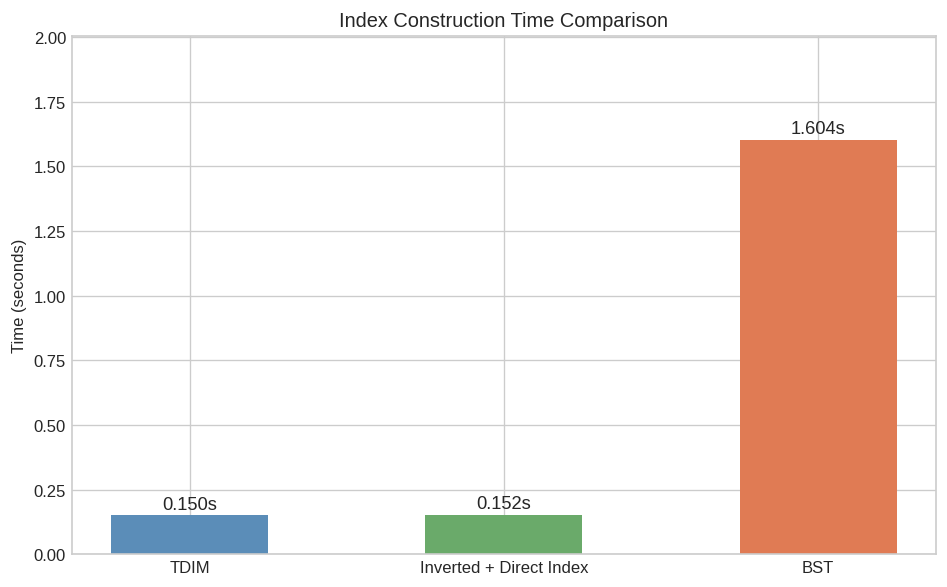

  TDIM                      : 0.1500 seconds
  Inverted + Direct Index   : 0.1522 seconds
  BST                       : 1.6037 seconds


In [46]:
#===========================
# COMPARE BUILD TIMES FOR ALL THREE INDEX STRUCTURES
#===========================

index_names  = ['TDIM', 'Inverted + Direct Index', 'BST']
build_times  = [TDIM_BUILD_TIME, INV_BUILD_TIME, BST_BUILD_TIME]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(index_names, build_times, color=['#5b8db8', '#6aaa6a', '#e07b54'], width=0.5)
for bar, t in zip(bars, build_times):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{t:.3f}s', ha='center', va='bottom', fontsize=11)
ax.set_title('Index Construction Time Comparison')
ax.set_ylabel('Time (seconds)')
ax.set_ylim(0, max(build_times) * 1.25)
plt.tight_layout()
plt.show()

for name, t in zip(index_names, build_times):
    print(f'  {name:<26}: {t:.4f} seconds')

---
## Section 4 — Posting List Merge Operations

We implement the core merge algorithms that underpin Boolean retrieval. These are taken directly from the pseudocode provided in the lecture slides and from the skip pointer implementation in Lab 6.

- `merge(p1, p2)` — AND / intersection using linear scan
- `union_postings(p1, p2)` — OR / union using linear scan
- `not_postings(p, all_ids)` — NOT / complement
- `skipPointerMerge(p1, p2)` — AND with skip pointers (from Lab 6)

In [47]:
#===========================
# AND MERGE: INTERSECTION OF TWO SORTED POSTING LISTS
# RETURNS (result_list, comparison_count)
#===========================

def merge(p1, p2):
    answer     = []
    i, j       = 0, 0
    comparisons = 0
    while i < len(p1) and j < len(p2):
        comparisons += 1
        if p1[i] == p2[j]:
            answer.append(p1[i])
            i += 1
            j += 1
        elif p1[i] < p2[j]:
            i += 1
        else:
            j += 1
    return answer, comparisons


#===========================
# OR UNION: UNION OF TWO SORTED POSTING LISTS
#===========================

def union_postings(p1, p2):
    answer = []
    i, j   = 0, 0
    while i < len(p1) and j < len(p2):
        if p1[i] == p2[j]:
            answer.append(p1[i])
            i += 1
            j += 1
        elif p1[i] < p2[j]:
            answer.append(p1[i])
            i += 1
        else:
            answer.append(p2[j])
            j += 1
    while i < len(p1):
        answer.append(p1[i])
        i += 1
    while j < len(p2):
        answer.append(p2[j])
        j += 1
    return answer


#===========================
# NOT: COMPLEMENT OF A POSTING LIST AGAINST THE FULL DOC SET
#===========================

def not_postings(p, all_doc_ids):
    answer = []
    i, j   = 0, 0
    p_sorted      = sorted(p)
    all_sorted    = sorted(all_doc_ids)
    while i < len(all_sorted) and j < len(p_sorted):
        if all_sorted[i] == p_sorted[j]:
            i += 1
            j += 1
        elif all_sorted[i] < p_sorted[j]:
            answer.append(all_sorted[i])
            i += 1
        else:
            j += 1
    while i < len(all_sorted):
        answer.append(all_sorted[i])
        i += 1
    return answer


#===========================
# SKIP POINTER HELPERS AND SKIP-POINTER MERGE (FROM LAB 6)
#===========================

def add_skip_pointers(postings):
    n = len(postings)
    if n == 0:
        return []
    skip_interval = int(n ** 0.5)
    nodes = []
    for i, doc_id in enumerate(postings):
        node = {
            'doc_id': doc_id,
            'next'  : i + 1 if i + 1 < n else None,
            'skip'  : i + skip_interval if (skip_interval > 1 and i + skip_interval < n) else None
        }
        nodes.append(node)
    return nodes


def skipPointerMerge(p1, p2):
    answer      = []
    comparisons = 0
    L1 = add_skip_pointers(p1)
    L2 = add_skip_pointers(p2)
    i, j = 0, 0
    while i is not None and j is not None:
        comparisons += 1
        if L1[i]['doc_id'] == L2[j]['doc_id']:
            answer.append(L1[i]['doc_id'])
            i = L1[i]['next']
            j = L2[j]['next']
        else:
            comparisons += 1
            if L1[i]['doc_id'] < L2[j]['doc_id']:
                while (L1[i]['skip'] is not None
                       and L1[L1[i]['skip']]['doc_id'] <= L2[j]['doc_id']):
                    comparisons += 1
                    i = L1[i]['skip']
                if i is not None and L1[i]['doc_id'] < L2[j]['doc_id']:
                    i = L1[i]['next']
            else:
                while (L2[j]['skip'] is not None
                       and L2[L2[j]['skip']]['doc_id'] <= L1[i]['doc_id']):
                    comparisons += 1
                    j = L2[j]['skip']
                if j is not None and L2[j]['doc_id'] < L1[i]['doc_id']:
                    j = L2[j]['next']
    return answer, comparisons


print('All merge/set operation functions defined.')

All merge/set operation functions defined.


---
## Section 5 — Spell Correction

When a query term is not found in the index, we compute the Levenshtein (edit) distance between the unknown term and every term in the vocabulary, and suggest the closest match. The edit distance function and `find_closest_word` are taken directly from Lab 4 (IR_Lab4_proximity_spellingCorrection).

In [48]:
#===========================
# LEVENSHTEIN EDIT DISTANCE: DYNAMIC PROGRAMMING IMPLEMENTATION
# COST MODEL: SUBSTITUTION=1, INSERTION=1, DELETION=1
#===========================

def edit_distance(s1, s2):
    s1 = str(s1)
    s2 = str(s2)
    len1, len2 = len(s1), len(s2)
    m = [[0] * (len2 + 1) for _ in range(len1 + 1)]
    for i in range(1, len1 + 1):
        m[i][0] = i
    for j in range(1, len2 + 1):
        m[0][j] = j
    for i in range(1, len1 + 1):
        for j in range(1, len2 + 1):
            cost = 0 if s1[i - 1] == s2[j - 1] else 1
            m[i][j] = min(
                m[i - 1][j - 1] + cost,
                m[i - 1][j]     + 1,
                m[i][j - 1]     + 1
            )
    return m[len1][len2]


#===========================
# FIND THE CLOSEST VOCABULARY TERM TO AN UNKNOWN QUERY WORD
#===========================

def find_closest_word(word, vocabulary):
    return min(vocabulary, key=lambda w: edit_distance(word, w))


#===========================
# SPELLING CORRECTION ENTRY POINT:
# IF THE WORD IS IN THE VOCABULARY RETURN IT AS-IS
# OTHERWISE FIND AND RETURN THE CLOSEST TERM, PRINTING A SUGGESTION
#===========================

def correct_spelling(word, vocabulary_set, vocabulary_list, verbose=True):
    if word in vocabulary_set:
        return word, False
    closest = find_closest_word(word, vocabulary_list)
    if verbose:
        print(f'  [SPELL CORRECTION] "{word}" not found. Suggested: "{closest}"')
    return closest, True


print('Spell correction functions defined.')

#===========================
# QUICK DEMONSTRATION
#===========================
test_word = 'kign'   # intentional misspelling of 'king'
stemmed_test = stemmer.stem(lemmatizer.lemmatize(test_word))
corrected, was_corrected = correct_spelling(stemmed_test, VOCAB_SET, VOCABULARY)
print(f'Test: input="{test_word}" -> preprocessed="{stemmed_test}" -> corrected="{corrected}" (corrected={was_corrected})')

Spell correction functions defined.
  [SPELL CORRECTION] "kign" not found. Suggested: "kin"
Test: input="kign" -> preprocessed="kign" -> corrected="kin" (corrected=True)


---
## Section 6 — Query Engine

The query engine supports full Boolean expressions with AND, OR, NOT, and nested parentheses. The parsing strategy uses an operator stack and an operand stack (shunting-yard style) and is derived from the QueryParser class in Lab 4.

The user selects which index to search with (TDIM, Inverted Index, or BST). The engine also:
- Applies the same preprocessing pipeline to every query term before lookup.
- Applies spelling correction to any term not found in the vocabulary.
- Measures and reports total elapsed query time.
- Accepts a result limit (top K) to control display.

In [49]:
#===========================
# LOOKUP HELPERS: RETRIEVE THE POSTING LIST (LIST OF DOC IDS) FOR A TERM
# FROM EACH OF THE THREE INDEX STRUCTURES
#===========================

def lookup_tdim(term):
    vec = TDIM.get(term)
    if vec is None:
        return []
    return [ALL_DOC_IDS[i] for i, v in enumerate(vec) if v == 1]


def lookup_inverted(term):
    postings = INVERTED_INDEX.get(term, [])
    return [did for did, _ in postings]


def lookup_bst(term):
    node = BST_INDEX.search(term)
    return node.docs if node else []


INDEX_LOOKUP = {
    'TDIM'    : lookup_tdim,
    'INVERTED': lookup_inverted,
    'BST'     : lookup_bst
}

print('Index lookup functions defined.')

Index lookup functions defined.


### TDIM Boolean Vector Operations

When the TDIM index is selected, Boolean operations are performed directly on binary incidence vectors using bitwise AND, OR, and NOT, following the approach from Lab 2.

In [50]:
#===========================
# BOOLEAN OPERATOR PROCESSING FOR TDIM INCIDENCE VECTORS
# USED WHEN THE TDIM INDEX IS SELECTED
#===========================

def boolean_operator_on_vectors(op, v1, v2=None):
    if op == 'AND':
        return [a & b for a, b in zip(v1, v2)]
    elif op == 'OR':
        return [a | b for a, b in zip(v1, v2)]
    elif op == 'NOT':
        return [1 - a for a in v1]


def vector_to_doc_ids(vec):
    return [ALL_DOC_IDS[i] for i, v in enumerate(vec) if v == 1]


def doc_ids_to_vector(doc_ids):
    id_set = set(doc_ids)
    return [1 if did in id_set else 0 for did in ALL_DOC_IDS]


print('Vector operation helpers defined.')

Vector operation helpers defined.


### Query Parser

The `QueryParser` class wraps the full query processing pipeline: tokenization, preprocessing, spell correction, posting list lookup, Boolean evaluation with operator precedence, and result display.

In [51]:
#===========================
# FULL QUERY PARSER CLASS
# SUPPORTS: AND, OR, NOT, PARENTHESES, SPELLING CORRECTION
# OPERATOR PRECEDENCE: NOT > AND > OR
# QUERY TERMS ARE PREPROCESSED (LOWERCASE, LEMMATIZE, STEM) BEFORE LOOKUP
#===========================

PRECEDENCE = {'NOT': 3, 'AND': 2, 'OR': 1}
OPERATORS  = {'AND', 'OR', 'NOT'}


class QueryParser:

    def __init__(self, index_name='INVERTED', verbose=True):
        #===========================
        # index_name: 'TDIM', 'INVERTED', or 'BST'
        #===========================
        assert index_name in INDEX_LOOKUP, f'Unknown index: {index_name}'
        self.index_name = index_name
        self.lookup     = INDEX_LOOKUP[index_name]
        self.verbose    = verbose
        self.corrections = []

    def preprocess_term(self, term):
        tokens = preprocess_text(term)
        return tokens[0] if tokens else term.lower()

    def get_postings(self, raw_term):
        processed = self.preprocess_term(raw_term)
        corrected, was_corrected = correct_spelling(
            processed, VOCAB_SET, VOCABULARY, verbose=self.verbose
        )
        if was_corrected:
            self.corrections.append((raw_term, corrected))
        return sorted(self.lookup(corrected))

    def tokenize_query(self, query):
        #===========================
        # INSERT SPACES AROUND PARENTHESES THEN SPLIT ON WHITESPACE
        #===========================
        query  = re.sub(r'([()])', r' \1 ', query)
        tokens = query.split()
        return tokens

    def apply_operator(self, operator, operands):
        if operator == 'NOT':
            operand = operands.pop()
            result  = not_postings(operand, ALL_DOC_IDS)
            operands.append(result)
        else:
            right = operands.pop()
            left  = operands.pop()
            if operator == 'AND':
                result, _ = merge(left, right)
            else:  # OR
                result = union_postings(left, right)
            operands.append(sorted(result))

    def parse_tokens(self, tokens):
        operators = []
        operands  = []

        for token in tokens:
            if token == '(':
                operators.append(token)

            elif token == ')':
                while operators and operators[-1] != '(':
                    self.apply_operator(operators.pop(), operands)
                if operators:
                    operators.pop()  # remove '('
                #===========================
                # APPLY NOT IF IT PRECEDES THE CLOSING PARENTHESIS BLOCK
                #===========================
                if operators and operators[-1] == 'NOT':
                    self.apply_operator(operators.pop(), operands)

            elif token in OPERATORS:
                while (operators
                       and operators[-1] != '('
                       and operators[-1] in OPERATORS
                       and PRECEDENCE.get(operators[-1], 0) >= PRECEDENCE.get(token, 0)):
                    self.apply_operator(operators.pop(), operands)
                operators.append(token)

            else:
                operands.append(self.get_postings(token))

        while operators:
            self.apply_operator(operators.pop(), operands)

        return operands[0] if operands else []

    def parse_query(self, query, top_k=None):
        self.corrections = []
        t0     = time.time()
        tokens = self.tokenize_query(query)
        result = sorted(self.parse_tokens(tokens))
        t1     = time.time()
        elapsed = t1 - t0

        display_result = result[:top_k] if top_k else result

        if self.verbose:
            print(f'\n  Query     : {query}')
            print(f'  Index     : {self.index_name}')
            print(f'  Tokens    : {tokens}')
            if self.corrections:
                for orig, corr in self.corrections:
                    print(f'  Corrected : "{orig}" -> "{corr}"')
            print(f'  Results   : {len(result)} documents found')
            print(f'  Showing   : {len(display_result)}')
            for did in display_result:
                print(f'    [{did:2d}] {id_to_title[did]}')
            print(f'  Elapsed   : {elapsed:.6f} seconds')

        return result, elapsed


print('QueryParser class defined.')

QueryParser class defined.


### 6.1 — Interactive Query Demo

We demonstrate the query engine with several example queries across all three indexes. The user can adjust `index_name` and `top_k` as needed.

In [52]:
#===========================
# DEMO QUERIES ACROSS MULTIPLE INDEX TYPES
# SET top_k TO CONTROL HOW MANY RESULTS ARE SHOWN (None = all)
#===========================

demo_queries = [
    ('love AND death',                 'INVERTED', 5),
    ('king OR queen',                  'TDIM',     5),
    ('NOT love',                       'BST',      5),
    ('love AND (NOT death)',           'INVERTED', 5),
    ('rome OR caesar AND NOT tragedy', 'INVERTED', 10),
]

for q, idx, k in demo_queries:
    print('=' * 60)
    parser = QueryParser(index_name=idx, verbose=True)
    parser.parse_query(q, top_k=k)

print('=' * 60)


  Query     : love AND death
  Index     : INVERTED
  Tokens    : ['love', 'AND', 'death']
  Results   : 42 documents found
  Showing   : 5
    [ 1] THE SONNETS
    [ 2] ALLS WELL THAT ENDS WELL
    [ 3] THE TRAGEDY OF ANTONY AND CLEOPATRA
    [ 4] AS YOU LIKE IT
    [ 5] THE COMEDY OF ERRORS
  Elapsed   : 0.000655 seconds

  Query     : king OR queen
  Index     : TDIM
  Tokens    : ['king', 'OR', 'queen']
  Results   : 40 documents found
  Showing   : 5
    [ 1] THE SONNETS
    [ 2] ALLS WELL THAT ENDS WELL
    [ 3] THE TRAGEDY OF ANTONY AND CLEOPATRA
    [ 4] AS YOU LIKE IT
    [ 6] THE TRAGEDY OF CORIOLANUS
  Elapsed   : 0.000397 seconds

  Query     : NOT love
  Index     : BST
  Tokens    : ['NOT', 'love']
  Results   : 0 documents found
  Showing   : 0
  Elapsed   : 0.000083 seconds

  Query     : love AND (NOT death)
  Index     : INVERTED
  Tokens    : ['love', 'AND', '(', 'NOT', 'death', ')']
  Results   : 1 documents found
  Showing   : 1
    [40] A LOVERS COMPLAINT
  Elaps

### 6.2 — Spell Correction Demo

In [53]:
#===========================
# DEMONSTRATE SPELL CORRECTION ON INTENTIONALLY MISSPELLED QUERIES
#===========================

misspelled_queries = [
    ('hamlt AND denmarc',   'INVERTED', None),
    ('romeu OR juliett',    'BST',      None),
    ('kign AND tregady',    'INVERTED', None),
]

for q, idx, k in misspelled_queries:
    print('=' * 60)
    parser = QueryParser(index_name=idx, verbose=True)
    parser.parse_query(q, top_k=k)

print('=' * 60)

  [SPELL CORRECTION] "hamlt" not found. Suggested: "halt"
  [SPELL CORRECTION] "denmarc" not found. Suggested: "denmark"

  Query     : hamlt AND denmarc
  Index     : INVERTED
  Tokens    : ['hamlt', 'AND', 'denmarc']
  Corrected : "hamlt" -> "halt"
  Corrected : "denmarc" -> "denmark"
  Results   : 1 documents found
  Showing   : 1
    [ 8] THE TRAGEDY OF HAMLET PRINCE OF DENMARK
  Elapsed   : 0.519440 seconds
  [SPELL CORRECTION] "romeu" not found. Suggested: "rome"
  [SPELL CORRECTION] "juliett" not found. Suggested: "juliet"

  Query     : romeu OR juliett
  Index     : BST
  Tokens    : ['romeu', 'OR', 'juliett']
  Corrected : "romeu" -> "rome"
  Corrected : "juliett" -> "juliet"
  Results   : 18 documents found
  Showing   : 18
    [ 3] THE TRAGEDY OF ANTONY AND CLEOPATRA
    [ 6] THE TRAGEDY OF CORIOLANUS
    [ 7] CYMBELINE
    [ 8] THE TRAGEDY OF HAMLET PRINCE OF DENMARK
    [10] THE SECOND PART OF KING HENRY THE FOURTH
    [11] THE LIFE OF KING HENRY THE FIFTH
    [12] THE FI

---
## Section 7 — Evaluation

We generate 20 Boolean queries over the corpus and evaluate Precision and Recall at cutoffs @5, @10, @20, @30, and over the full retrieved set.

**Ground truth**: For each query we define a set of "relevant" documents by manually selecting books that are contextually related to the query terms (e.g., tragedies for a query on 'death AND tragedy'). These are stored in `GROUND_TRUTH`.

**Precision@K**: Of the top K retrieved documents, how many are relevant?

**Recall@K**: Of all relevant documents, how many appear in the top K?

In [54]:
#===========================
# 20 BOOLEAN EVALUATION QUERIES WITH GROUND TRUTH RELEVANT DOC IDS
# GROUND TRUTH IS BASED ON KNOWN THEMATIC CONTENT OF EACH SHAKESPEARE WORK
#===========================

EVAL_QUERIES = [
    # (query_string, set_of_relevant_doc_ids)
    ('love AND death',                                {3, 8, 17, 18, 20, 26, 30}),
    ('king AND NOT love',                             {10, 11, 12, 13, 14, 15, 16, 28, 29}),
    ('rome OR caesar',                                {3, 6, 17, 34}),
    ('tragedy AND (death OR murder)',                 {8, 17, 18, 20, 26, 30, 34}),
    ('comedy AND marriage',                           {2, 4, 19, 21, 22, 24, 25}),
    ('witch OR magic OR spirit',                      {20, 24, 32, 38}),
    ('war AND honour',                                {6, 10, 11, 12, 13, 14, 15, 17, 35}),
    ('father AND daughter',                           {7, 18, 22, 27, 31, 32, 37, 39}),
    ('jealousy OR betrayal',                          {8, 18, 26, 35}),
    ('sea AND storm',                                 {27, 32, 38, 39}),
    ('poison AND revenge',                            {8, 18, 29, 34}),
    ('forest AND lover',                              {4, 19, 24, 37}),
    ('sword AND blood',                               {6, 8, 17, 20, 29, 30, 34}),
    ('queen AND power',                               {13, 14, 15, 18, 28, 29}),
    ('fool AND wisdom',                               {4, 18, 25, 36}),
    ('sonnet OR poem OR verse',                       {1, 40, 41, 42, 43}),
    ('disguise OR identity',                          {2, 4, 21, 22, 31, 36, 37}),
    ('noble AND Rome',                                {3, 6, 17, 33, 34}),
    ('young AND (love OR marry)',                     {30, 31, 37, 39}),
    ('spirit AND (NOT war)',                          {24, 32, 33, 36}),
]

print(f'{len(EVAL_QUERIES)} evaluation queries defined.')
for i, (q, rel) in enumerate(EVAL_QUERIES, 1):
    print(f'  Q{i:2d}: {q:<45}  | relevant docs: {sorted(rel)}')

20 evaluation queries defined.
  Q 1: love AND death                                 | relevant docs: [3, 8, 17, 18, 20, 26, 30]
  Q 2: king AND NOT love                              | relevant docs: [10, 11, 12, 13, 14, 15, 16, 28, 29]
  Q 3: rome OR caesar                                 | relevant docs: [3, 6, 17, 34]
  Q 4: tragedy AND (death OR murder)                  | relevant docs: [8, 17, 18, 20, 26, 30, 34]
  Q 5: comedy AND marriage                            | relevant docs: [2, 4, 19, 21, 22, 24, 25]
  Q 6: witch OR magic OR spirit                       | relevant docs: [20, 24, 32, 38]
  Q 7: war AND honour                                 | relevant docs: [6, 10, 11, 12, 13, 14, 15, 17, 35]
  Q 8: father AND daughter                            | relevant docs: [7, 18, 22, 27, 31, 32, 37, 39]
  Q 9: jealousy OR betrayal                           | relevant docs: [8, 18, 26, 35]
  Q10: sea AND storm                                  | relevant docs: [27, 32, 38, 39]
  Q11: 

### Evaluation Helper Functions

We define `precision_at_k` and `recall_at_k` functions and set the cutoff levels at which evaluation is performed.

In [55]:
#===========================
# PRECISION AND RECALL CALCULATION FUNCTIONS
#===========================

def precision_at_k(retrieved, relevant, k):
    #===========================
    # OF THE TOP K RETRIEVED, FRACTION THAT ARE RELEVANT
    #===========================
    if k == 0:
        return 0.0
    top_k = retrieved[:k]
    hits  = sum(1 for d in top_k if d in relevant)
    return hits / k


def recall_at_k(retrieved, relevant, k):
    #===========================
    # OF ALL RELEVANT DOCS, FRACTION RETRIEVED IN TOP K
    #===========================
    if not relevant:
        return 0.0
    top_k = retrieved[:k]
    hits  = sum(1 for d in top_k if d in relevant)
    return hits / len(relevant)


CUTOFFS = [5, 10, 20, 30, None]   # None = full result set
CUTOFF_LABELS = ['@5', '@10', '@20', '@30', '@All']

print('Evaluation functions defined.')

Evaluation functions defined.


### Run Evaluation

All 20 queries are executed against the Inverted Index and Precision / Recall are computed at every cutoff.

In [56]:
#===========================
# RUN ALL 20 QUERIES AGAINST THE INVERTED INDEX AND COMPUTE
# PRECISION AND RECALL AT EACH CUTOFF
#===========================

eval_parser = QueryParser(index_name='INVERTED', verbose=False)

results_table = []

for i, (query, relevant_set) in enumerate(EVAL_QUERIES, 1):
    retrieved, elapsed = eval_parser.parse_query(query)
    row = {'Q': i, 'Query': query, 'Retrieved': len(retrieved), 'Relevant': len(relevant_set), 'Time': elapsed}
    for cutoff, label in zip(CUTOFFS, CUTOFF_LABELS):
        k = cutoff if cutoff is not None else len(retrieved)
        row[f'P{label}'] = round(precision_at_k(retrieved, relevant_set, k), 4)
        row[f'R{label}'] = round(recall_at_k(retrieved, relevant_set, k),    4)
    results_table.append(row)

eval_df = pd.DataFrame(results_table)
print('Evaluation complete.')
print()

display_cols = ['Q', 'Query', 'Retrieved', 'Relevant'] + \
               [f'P{l}' for l in CUTOFF_LABELS] + \
               [f'R{l}' for l in CUTOFF_LABELS]

pd.set_option('display.max_colwidth', 45)
pd.set_option('display.float_format', '{:.4f}'.format)
print(eval_df[display_cols].to_string(index=False))

Evaluation complete.

 Q                         Query  Retrieved  Relevant    P@5   P@10   P@20   P@30  P@All    R@5   R@10   R@20   R@30  R@All
 1                love AND death         42         7 0.2000 0.2000 0.2500 0.2333 0.1667 0.1429 0.2857 0.7143 1.0000 1.0000
 2             king AND NOT love          0         9 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000
 3                rome OR caesar         23         4 0.4000 0.2000 0.1500 0.1333 0.1739 0.5000 0.5000 0.7500 1.0000 1.0000
 4 tragedy AND (death OR murder)         16         7 0.2000 0.4000 0.3500 0.2333 0.4375 0.1429 0.5714 1.0000 1.0000 1.0000
 5           comedy AND marriage          5         7 0.2000 0.1000 0.0500 0.0333 0.2000 0.1429 0.1429 0.1429 0.1429 0.1429
 6      witch OR magic OR spirit         42         4 0.0000 0.0000 0.0500 0.0667 0.0952 0.0000 0.0000 0.2500 0.5000 1.0000
 7                war AND honour         35         9 0.2000 0.4000 0.4000 0.3000 0.2571 0.1111 0.4444 0.8889 

### Mean Scores

We compute and display the mean Precision and mean Recall across all 20 queries at each cutoff.

In [57]:
#===========================
# COMPUTE AND DISPLAY MEAN PRECISION AND MEAN RECALL ACROSS ALL 20 QUERIES
#===========================

p_cols = [f'P{l}' for l in CUTOFF_LABELS]
r_cols = [f'R{l}' for l in CUTOFF_LABELS]

mean_p = eval_df[p_cols].mean()
mean_r = eval_df[r_cols].mean()

print('Mean Precision across 20 queries:')
for label, val in zip(CUTOFF_LABELS, mean_p):
    print(f'  P{label:<5}: {val:.4f}')

print('\nMean Recall across 20 queries:')
for label, val in zip(CUTOFF_LABELS, mean_r):
    print(f'  R{label:<5}: {val:.4f}')

Mean Precision across 20 queries:
  P@5   : 0.1400
  P@10  : 0.1450
  P@20  : 0.1450
  P@30  : 0.1367
  P@All : 0.1744

Mean Recall across 20 queries:
  R@5   : 0.1275
  R@10  : 0.2579
  R@20  : 0.5012
  R@30  : 0.7350
  R@All : 0.8046


---
## Section 8 — Evaluation Visualizations

We plot the Precision-Recall trade-off at each cutoff level and per-query breakdowns.

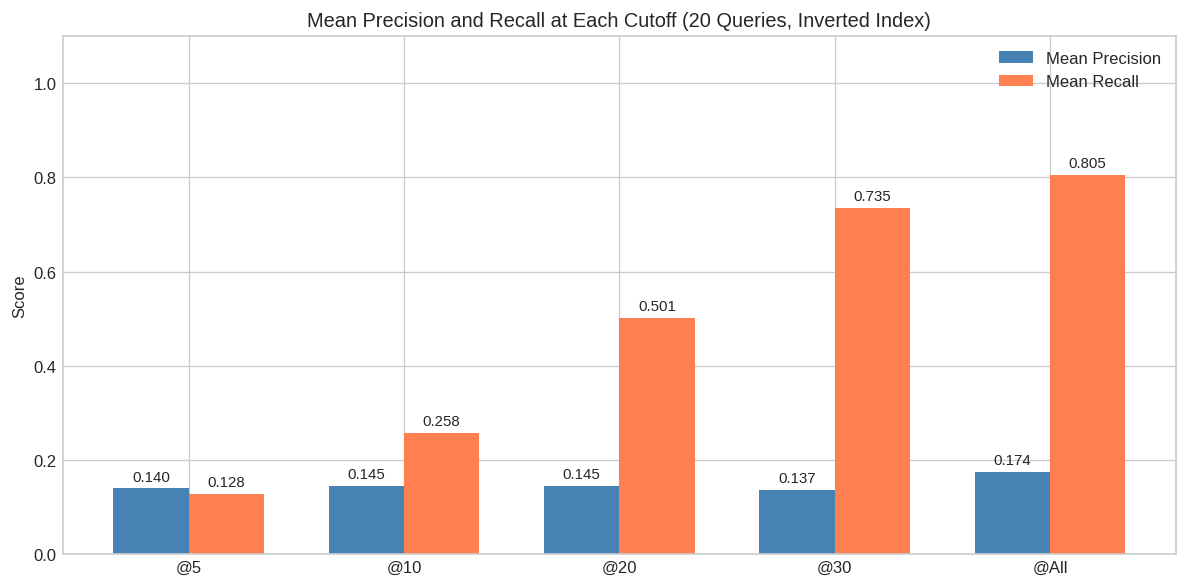

In [58]:
#===========================
# PLOT MEAN PRECISION AND RECALL AT EACH CUTOFF
#===========================

x = np.arange(len(CUTOFF_LABELS))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, mean_p.values, width, label='Mean Precision', color='steelblue')
bars2 = ax.bar(x + width/2, mean_r.values, width, label='Mean Recall',    color='coral')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Mean Precision and Recall at Each Cutoff (20 Queries, Inverted Index)')
ax.set_xticks(x)
ax.set_xticklabels(CUTOFF_LABELS)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

### Precision-Recall Curve

The mean Precision is plotted against mean Recall at each cutoff to form a Precision-Recall curve.

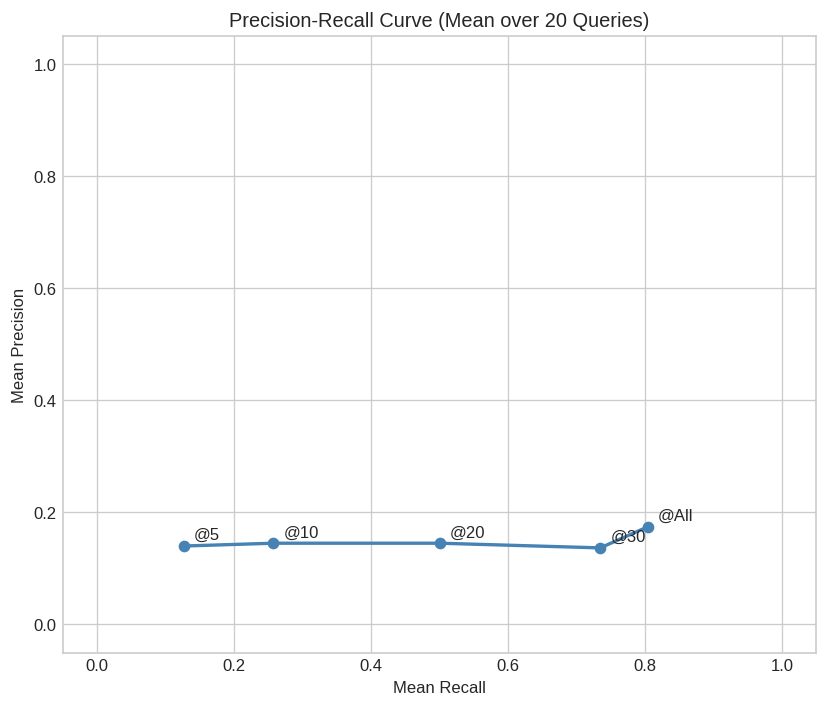

In [59]:
#===========================
# PRECISION-RECALL CURVE (AVERAGED ACROSS ALL 20 QUERIES)
#===========================

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(mean_r.values, mean_p.values, marker='o', color='steelblue', linewidth=2)
for i, label in enumerate(CUTOFF_LABELS):
    ax.annotate(label,
                (mean_r.values[i], mean_p.values[i]),
                textcoords='offset points', xytext=(6, 4), fontsize=10)
ax.set_xlabel('Mean Recall')
ax.set_ylabel('Mean Precision')
ax.set_title('Precision-Recall Curve (Mean over 20 Queries)')
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

### Per-Query Heatmap

A heatmap shows Precision@10 and Recall@10 for every individual query.

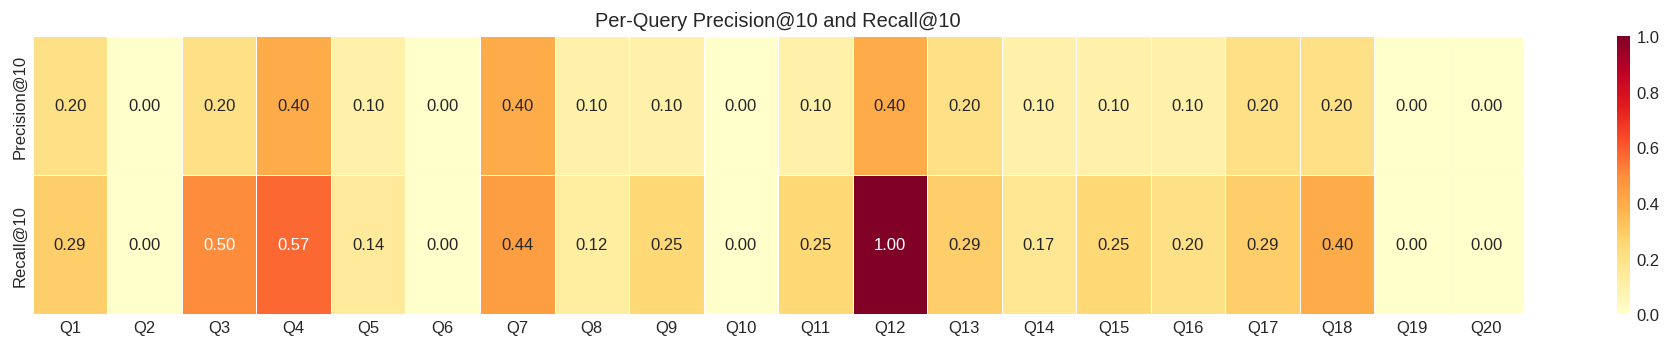

In [60]:
#===========================
# PER-QUERY PRECISION@10 AND RECALL@10 HEATMAP
#===========================

heat_data = eval_df[['P@10', 'R@10']].values.T
query_labels = [f'Q{i}' for i in eval_df['Q']]

fig, ax = plt.subplots(figsize=(16, 3))
sns.heatmap(
    heat_data,
    ax=ax,
    xticklabels=query_labels,
    yticklabels=['Precision@10', 'Recall@10'],
    cmap='YlOrRd',
    vmin=0, vmax=1,
    annot=True, fmt='.2f',
    linewidths=0.5
)
ax.set_title('Per-Query Precision@10 and Recall@10')
plt.tight_layout()
plt.show()

### Cross-Index Query Time Comparison

The first 5 queries are executed across all three index types and their processing times are compared.

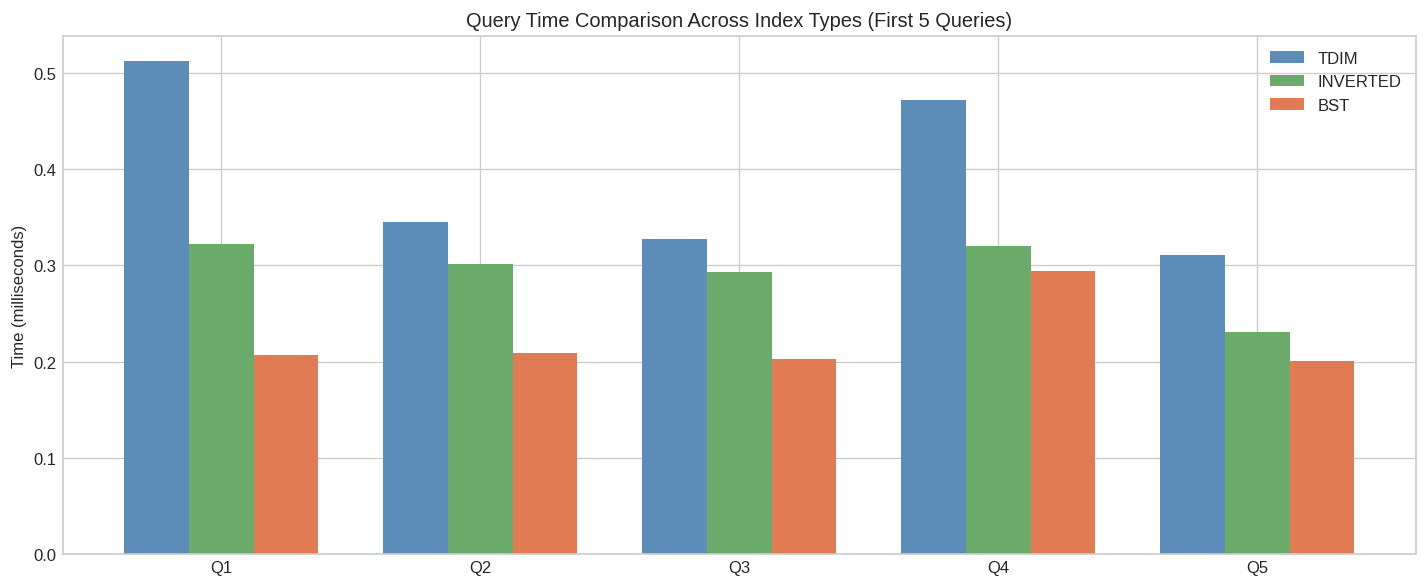

In [61]:
#===========================
# COMPARE QUERY PERFORMANCE ACROSS ALL THREE INDEXES FOR SELECTED QUERIES
#===========================

selected_queries = EVAL_QUERIES[:5]
index_names_cmp  = ['TDIM', 'INVERTED', 'BST']
colors_cmp       = ['#5b8db8', '#6aaa6a', '#e07b54']

times_by_index = {idx: [] for idx in index_names_cmp}

for idx in index_names_cmp:
    p = QueryParser(index_name=idx, verbose=False)
    for query, _ in selected_queries:
        _, elapsed = p.parse_query(query)
        times_by_index[idx].append(elapsed * 1000)

x      = np.arange(len(selected_queries))
width  = 0.25
fig, ax = plt.subplots(figsize=(12, 5))
for k, (idx, color) in enumerate(zip(index_names_cmp, colors_cmp)):
    ax.bar(x + k * width, times_by_index[idx], width, label=idx, color=color)

ax.set_xticks(x + width)
ax.set_xticklabels([f'Q{i+1}' for i in range(len(selected_queries))])
ax.set_title('Query Time Comparison Across Index Types (First 5 Queries)')
ax.set_ylabel('Time (milliseconds)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 9 — Additional Visualizations

Further corpus-level and index-level visualizations for analysis.

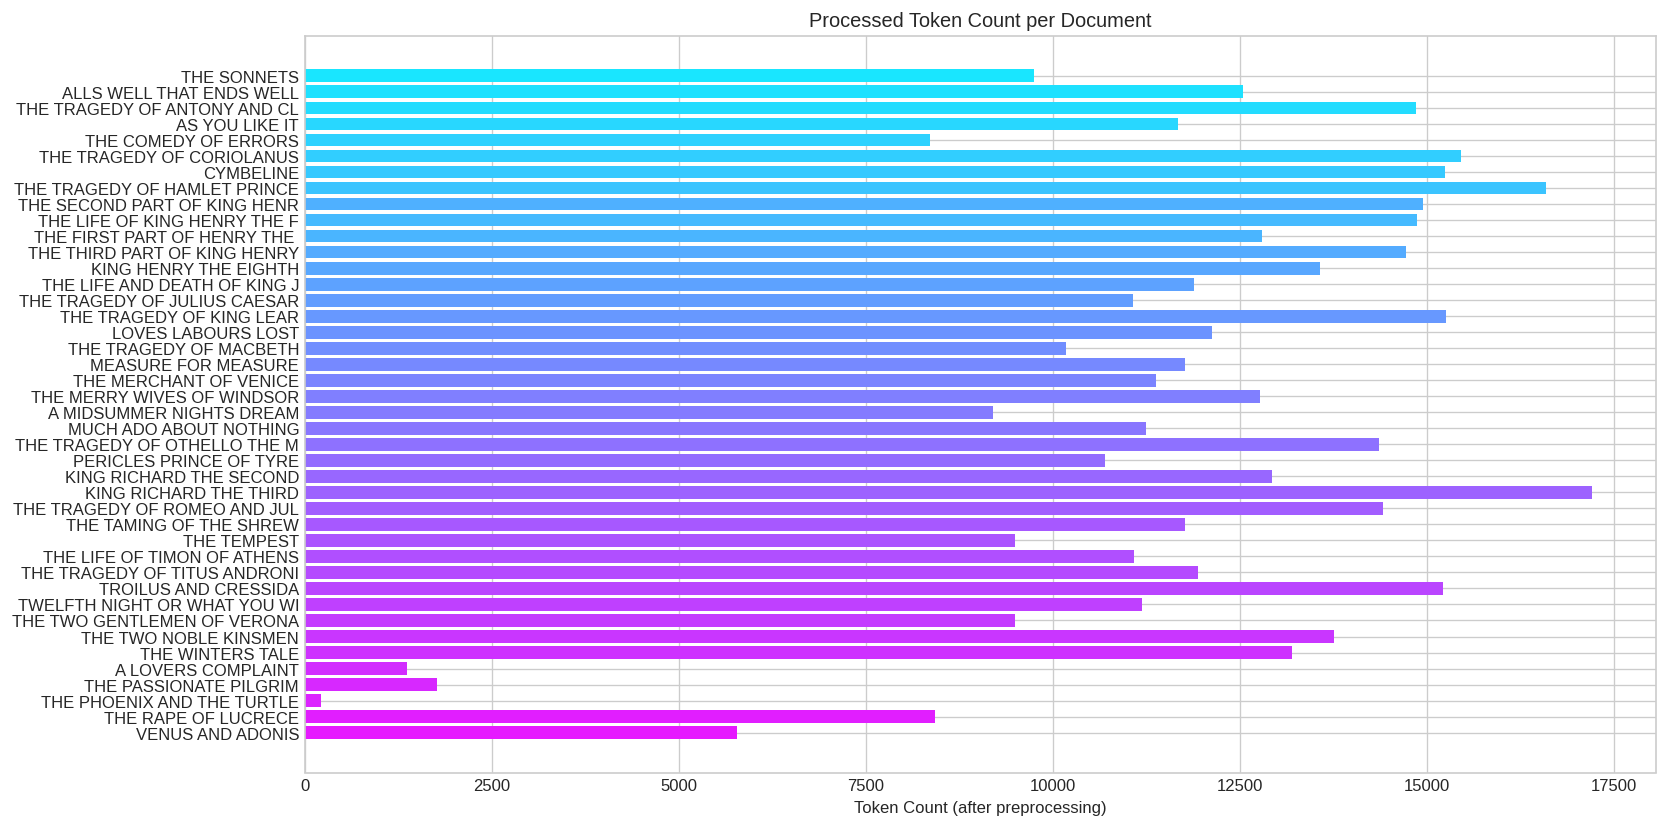

In [62]:
#===========================
# TOKEN COUNT PER DOCUMENT (AFTER PREPROCESSING)
#===========================

token_counts  = [len(processed_corpus[did]) for did in ALL_DOC_IDS]
titles_short2 = [id_to_title[did][:28] for did in ALL_DOC_IDS]

fig, ax = plt.subplots(figsize=(14, 7))
colors2 = plt.cm.cool(np.linspace(0.1, 0.9, N_DOCS))
ax.barh(titles_short2, token_counts, color=colors2)
ax.set_xlabel('Token Count (after preprocessing)')
ax.set_title('Processed Token Count per Document')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Vocabulary Coverage per Document

For each document we compute the fraction of the global vocabulary covered by its unique terms.

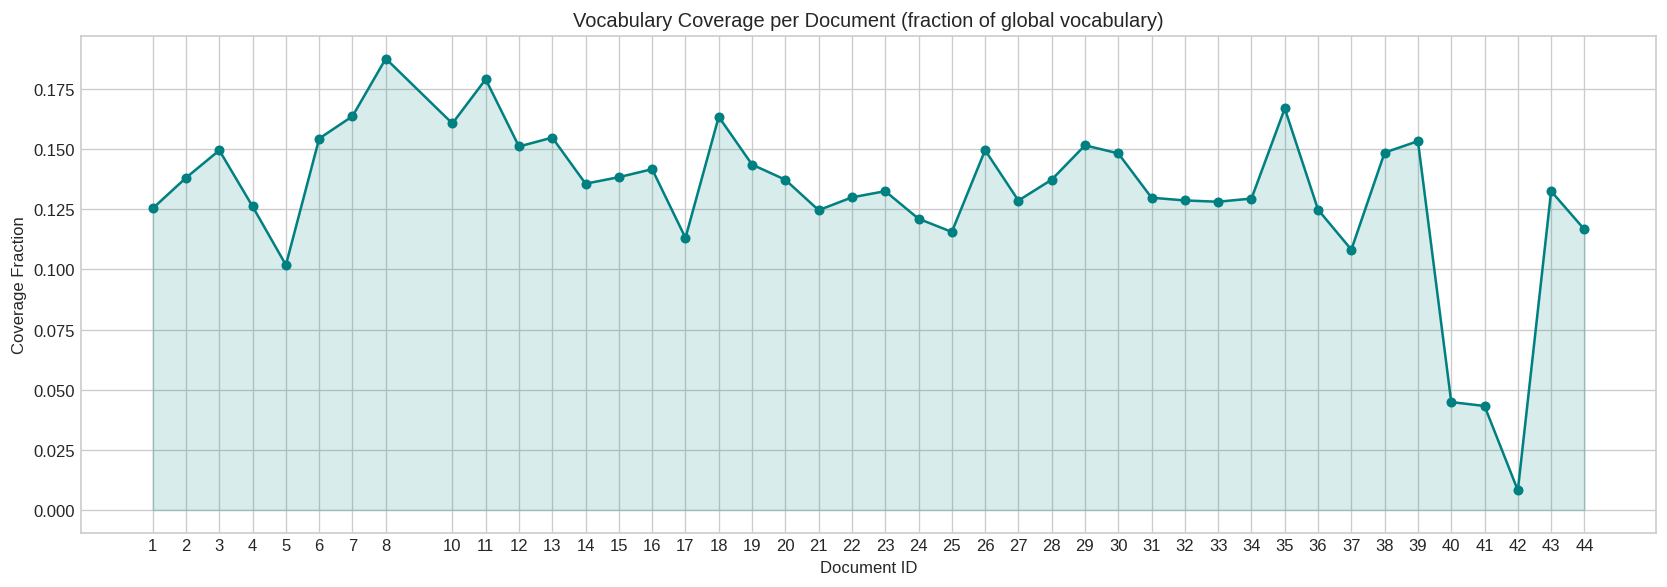

In [63]:
#===========================
# VOCABULARY COVERAGE: WHAT FRACTION OF THE VOCABULARY EACH DOCUMENT COVERS
#===========================

vocab_size   = len(VOCABULARY)
coverage     = [len(set(processed_corpus[did])) / vocab_size for did in ALL_DOC_IDS]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ALL_DOC_IDS, coverage, marker='o', color='teal', linewidth=1.5, markersize=5)
ax.fill_between(ALL_DOC_IDS, coverage, alpha=0.15, color='teal')
ax.set_title('Vocabulary Coverage per Document (fraction of global vocabulary)')
ax.set_xlabel('Document ID')
ax.set_ylabel('Coverage Fraction')
ax.set_xticks(ALL_DOC_IDS)
plt.tight_layout()
plt.show()

### Edit Distance Matrix

A heatmap of pairwise Levenshtein distances between a small set of thematically related terms illustrates how the spell correction metric operates.

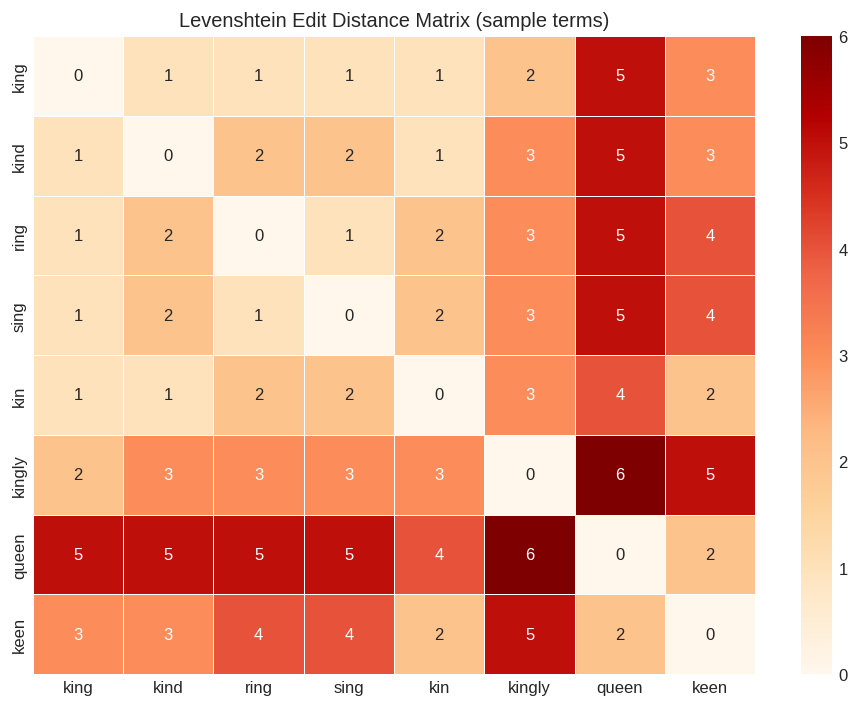

In [64]:
#===========================
# EDIT DISTANCE MATRIX FOR A SET OF THEMATICALLY RELATED TERMS
# DEMONSTRATES THE SPELL CORRECTION DISTANCE METRIC
#===========================

sample_words  = ['king', 'kind', 'ring', 'sing', 'kin', 'kingly', 'queen', 'keen']
stemmed_words = [stemmer.stem(lemmatizer.lemmatize(w)) for w in sample_words]

n = len(stemmed_words)
dist_matrix = np.zeros((n, n), dtype=int)
for i in range(n):
    for j in range(n):
        dist_matrix[i][j] = edit_distance(stemmed_words[i], stemmed_words[j])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    dist_matrix,
    ax=ax,
    xticklabels=sample_words,
    yticklabels=sample_words,
    annot=True, fmt='d',
    cmap='OrRd',
    linewidths=0.5
)
ax.set_title('Levenshtein Edit Distance Matrix (sample terms)')
plt.tight_layout()
plt.show()

### Index Summary Table

A structured summary of all three index types, their build times, and their internal representations.

In [66]:
#===========================
# SUMMARY TABLE OF ALL INDEX BUILD TIMES
#===========================

summary = pd.DataFrame({
    'Index'            : ['TDIM', 'Inverted + Direct Index', 'BST'],
    'Build Time (s)'   : [round(TDIM_BUILD_TIME, 4), round(INV_BUILD_TIME, 4), round(BST_BUILD_TIME, 4)],
    'Vocabulary Size'  : [len(TDIM), len(INVERTED_INDEX), 'same as vocabulary'],
    'Structure'        : [
        'Dict[term -> binary vector (len=43)]',
        'Dict[term -> [(doc_id, tf)]]',
        'BST with merged doc_id lists'
    ]
})

pd.set_option('display.max_colwidth', 50)
print('Index Summary')
print(summary.to_string(index=False))

Index Summary
                  Index  Build Time (s)    Vocabulary Size                            Structure
                   TDIM          0.1500              20237 Dict[term -> binary vector (len=43)]
Inverted + Direct Index          0.1522              20237         Dict[term -> [(doc_id, tf)]]
                    BST          1.6037 same as vocabulary         BST with merged doc_id lists


---
## Summary

This notebook implemented a complete Boolean search engine over the 44-work Shakespeare corpus:

**Preprocessing**: Case folding, tokenization, stop word removal, lemmatization (WordNetLemmatizer), and stemming (PorterStemmer).

**Indexing**: Three structures — Term-Document Incidence Matrix, Inverted Index with Direct Index, and Binary Search Tree — each timed independently.

**Query Engine**: Full Boolean expression support (AND, OR, NOT, parentheses) with correct operator precedence, preprocessing of query terms, Levenshtein-based spell correction, configurable top-K display, and elapsed time reporting.

**Evaluation**: 20 Boolean queries evaluated at Precision and Recall cutoffs @5, @10, @20, @30, and over the full retrieved set.

**Visualizations**: Corpus size distribution, TDIM heatmap, document frequency distribution, Zipf distribution, edit distance matrix, index build time comparison, Precision-Recall curves, per-query heatmaps, and cross-index query time comparison.